In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def permutation_test_correlation(x,y,x_name='X',y_name='Y',num_permutations=1000):
    x=np.array(x)
    y=np.array(y)

    n=len(x)
    mean_x=x.mean()
    mean_y=y.mean()
    std_x = x.std(ddof=1)
    std_y = y.std(ddof=1)

    #Scatter plot of X,Y
    plt.figure(figsize=(6,4))
    plt.scatter(x,y,alpha=0.7)
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.title(f'{x_name} vs. {y_name}')

    #Correlation Coef.
    num = np.sum((x-mean_x)*(y-mean_y))
    den = (n-1) * std_x * std_y
    r_obs = num/den

    #Permutation Test
    rList = []
    for _ in range(num_permutations):
        shuffled_y = np.random.permutation(y)
        num = np.sum((x-mean_x)*(shuffled_y-mean_y))
        rList.append(num/den)
    rArray = np.array(rList)

    if r_obs >=0:
        p_val = np.mean(rArray>=r_obs)
    else:
        p_val = np.mean(rArray<=r_obs)

    #Plot the Permutation Histogram
    plt.figure(figsize=(6,4))
    plt.hist(rArray,bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(r_obs,color='red',linestyle='--', label = f'Observed r = {r_obs:.3f}')
    plt.xlabel('Permuted Correlation (r)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.title(f'Permutation Test: {x_name} & {y_name}')

    print(f'--- Results for {x_name} and {y_name}---')
    print(f' Pearson correlation: {r_obs:.4f}')
    print(f'p-value(one-sided): {p_val:.4f}\n')

    return r_obs, p_val

--- Results for Training and Productivity---
 Pearson correlation: 0.9881
p-value(one-sided): 0.0000



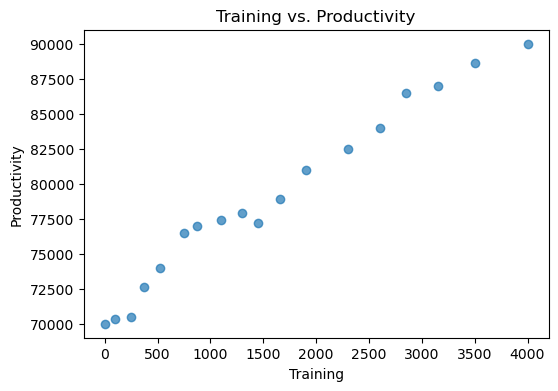

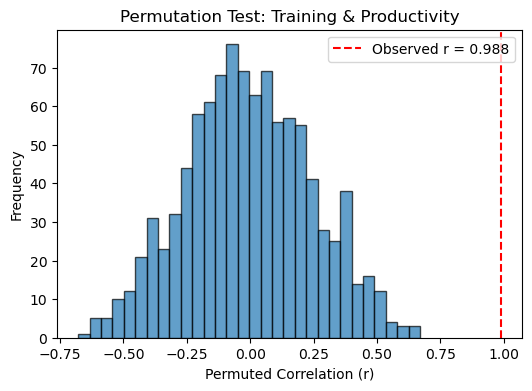

In [6]:
df1 = pd.read_csv('delta-wire.csv')
r, p = permutation_test_correlation(df1['training'],df1['productivity'],'Training','Productivity')

--- Results for Exposure and PEFR---
 Pearson correlation: -0.2770
p-value(one-sided): 0.0010



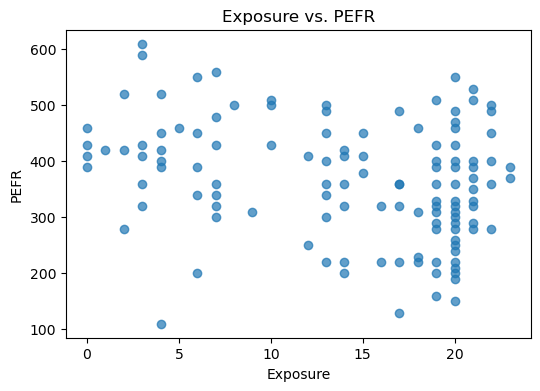

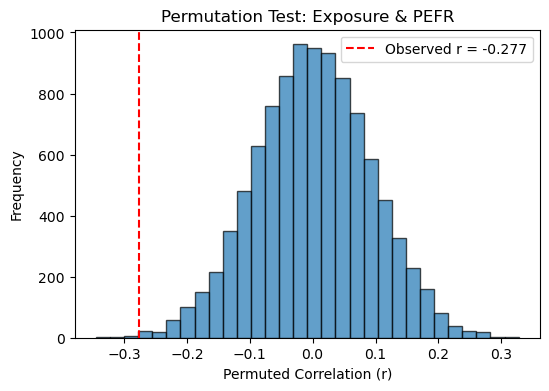

In [10]:
df2 = pd.read_csv('pefr.txt',sep=r'\s+')
r, p = permutation_test_correlation(df2['exposure'],df2['pefr'],'Exposure','PEFR',10000)

--- Results for Average Payroll (Million) and Total Wins---
 Pearson correlation: 0.6335
p-value(one-sided): 0.0000



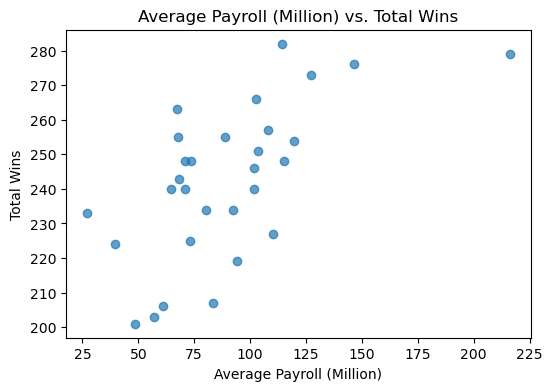

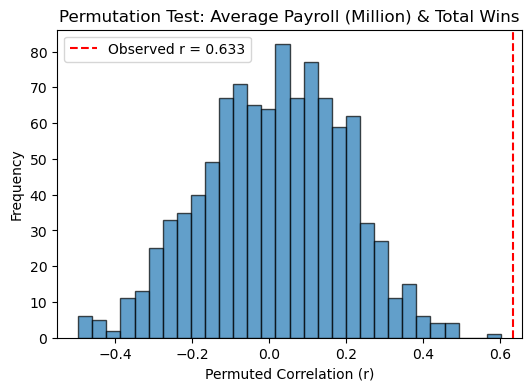

In [12]:
df3 = pd.read_csv('baseball_payroll.csv')
r, p = permutation_test_correlation(df3['Average Payroll (Million)'],df3['Total Wins'],'Average Payroll (Million)','Total Wins')